# PDE3 Workshop 5

## Bounus Section: Modelling a Tsunami

In this bonus question, we will model the movement of a tsunami using the advection equation.

The tsunami is modelled as a Gaussian pulse given by 

$$u(x,0) = e^{-\frac{(x-0.5)^2}{0.01}}$$

The tsunami moves at a speed of 20 km/h.

Run the cell below before continuing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from schemes import Lax_Friedrichs, Lax_Wendroff, MacCormack, generate_grid, solver

### a)

Write a function called ``implement_tsunami()`` which takes in ``xs``, a numpy array of the $x$ coordinates and returns ``us `` implementing the initial condition for the tsunami.
This should work in a similar way to the ``implement_initial()`` function you wrote earlier.

You should then plot the initial condition.

In [2]:
# Your code here:

### BEGIN SOLUTION ###

def implement_tsunami(xs: np.ndarray) -> np.ndarray:
    """Implement the boundary conditions on the solution array $u$."""
    
    us = np.zeros_like(xs, dtype=float)
    N = xs.size
    us = np.exp(-(xs-0.5)**2/0.01)

    return us

### END SOLUTION ###

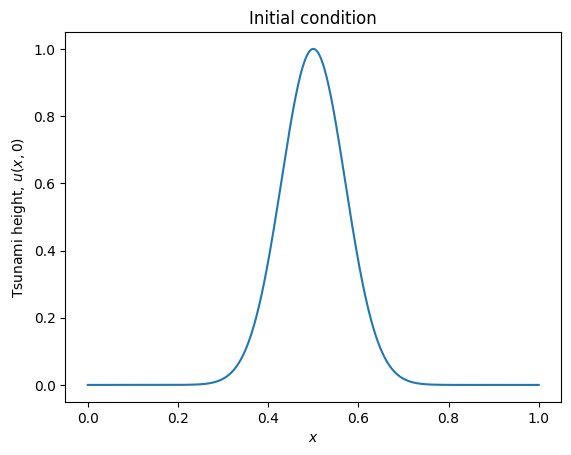

In [3]:
# Plot your initial conditions here:

### BEGIN SOLUTION ###

dx, xs = generate_grid(1000)
us = implement_tsunami(xs)

plt.plot(xs, us)
plt.title("Initial condition")
plt.xlabel("$x$")
plt.ylabel("Tsunami height, $u(x,0)$")
plt.show()

### END SOLUTION ###

### b)

Create a modified version of the ``FOU`` function which we wrote earlier, called ``FOU_forwards`` which implements the First-Order Upwind scheme for forwards advection.

In [4]:
# Your code here:

### BEGIN SOLUTION ###

def FOU_forwards(us: np.ndarray, a: float, dt: float, dx: float) -> np.ndarray:
    """Implement the First-Order Upwind scheme for a single timestep and return the updated solution array."""

    us_new = us - a*dt/dx*(us - np.roll(us, 1))

    return us_new

### END SOLUTION ###

### c)

Model the tsunami using the First-Order Upwind scheme for forwards advection and compare its performance with another suitable scheme from those used in Section 2.

You should use a grid with 5000 points and should model the system after 1,2,4 and 8 hours.

[**Hint:** The schemes used in Section 2 have all been written to handle both forwards and backwards advection.]

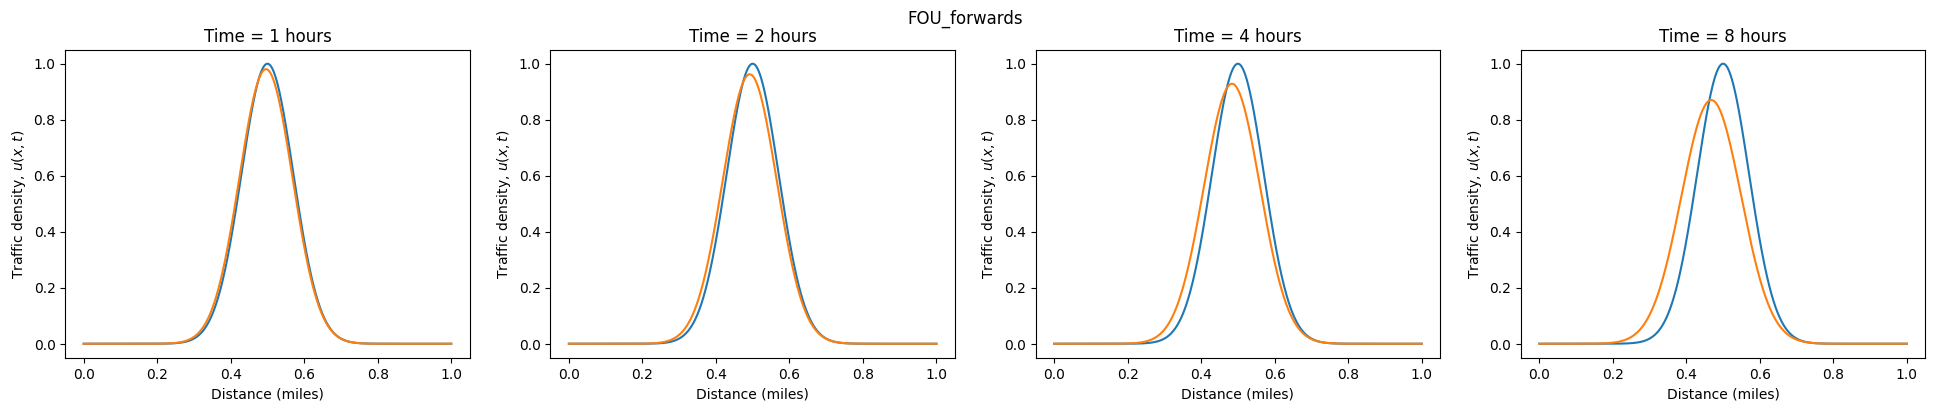

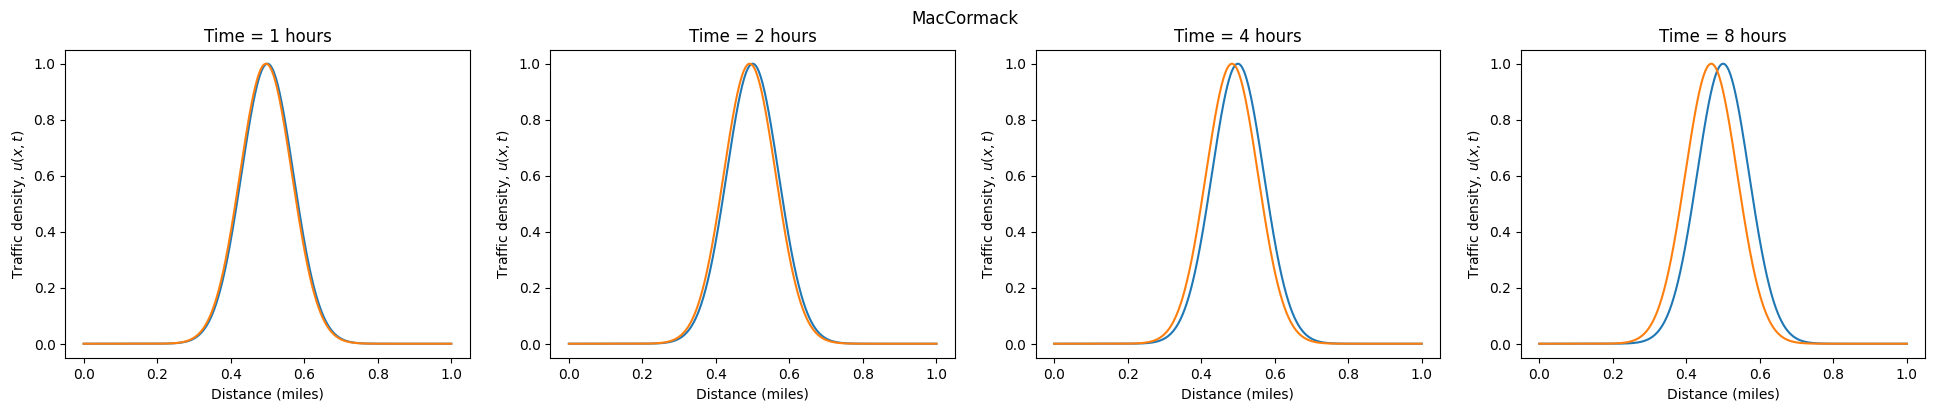

In [5]:
# Your code here:

### BEGIN SOLUTION ###
for scheme in [FOU_forwards, MacCormack]:

    fig, axs = plt.subplots(1,4, figsize=(24,4))

    for i, time in enumerate([1,2,4,8]):
        dx, xs = generate_grid(5000)
        u = implement_tsunami(xs)
        bcs = u.copy()
        a = 20.0

        us, ts = solver(scheme, bcs, a, dx, time)


        axs[i].plot(xs, bcs)
        axs[i].plot(xs,us)
        axs[i].set_title(f'Time = {time} hours')
        axs[i].set_xlabel('Distance (miles)')
        axs[i].set_ylabel('Traffic density, $u(x,t)$')
    
    fig.suptitle(f'{scheme.__name__}')

### END SOLUTION ###

### d)

Discuss how the model can be made more realistic to model a tsunami wave.

<font color='orange'>Your answer here. Double click to edit.</font>

<font color='red'>

### Some possible arguments:

- The model that we have used is purely advective so it does not account for any dissipation or dispersion of the wave. This means that the wave will not change shape as it moves (other than because of numerical effects).
- The advection speed is constant. While this might be a reasonable assumption when the tsunami is far from shore, it is likely to be less accurate as the wave approaches the coast.
- The advection speed of the tsunami is also too slow (typically it should be up to 800 km/h in open ocean).
- We model the wave as a 1D Gaussian pulse. Again, this may be a reasonable assumption when the wave is in deep water, though not as the wave approaches the shore.

</font>